# 07 — Selección operativa: D2 como alerta + D6 como confirmación

Este notebook busca una alternativa más sólida que D7+D8 sin ocultar el criterio de selección. D6 (GJR-GARCH-t) se fija como confirmador por su estabilidad y fortaleza en la pista B; después se comparan los otros 11 detectores como capa de alerta bajo la misma máquina causal de `src/fusion.py` (la misma que el notebook 06).

**Estado del resultado:** D2+D6 es una *propuesta* para la prueba pseudolive, no un resultado validado. La sección 5 cuantifica cuánto puede deberse a haberla elegido con la misma muestra con la que se evalúa.

## Criterio de selección y sus límites

Se exige estabilidad mínima de etiquetas del 99% en ambas pistas. Entre los candidatos elegibles se maximiza un índice operativo descriptivo (`src.fusion.operational_utility`):

`utilidad = cobertura_crisis − falsas_alarmas − activación_trampas − 5 × tasa_cambios`.

- El factor 5 hace visible el coste de una señal nerviosa; no representa rentabilidad ni se ha optimizado. El índice solo sirve para **ordenar** alternativas con las mismas labels: su valor absoluto no tiene lectura directa (una señal *siempre activa* obtiene `−(fracción de días fuera de crisis)`, y una que nunca se activa no tiene tasa de falsas alarmas definida).
- **Sesgo de selección (comparaciones múltiples).** Se eligen 1 de 11 alertas con las mismas crisis que luego se usan para puntuar. Además, D6 como confirmador, el umbral 0,50, la persistencia 3 y el horizonte 63 ya se habían fijado tras ver el benchmark (05) y el notebook 06, y la estabilidad de etiquetas que filtra candidatos es un diagnóstico de muestra completa. La utilidad de la pareja ganadora en muestra completa está, por tanto, **sesgada al alza**; la sección 5 lo mide de forma barata (seleccionar en una mitad temporal, evaluar en la otra).
- Las decisiones sí son causales: cada decisión en `t` usa solo paneles OOS ≤ `t` (`assert_prefix_causal`).

In [1]:
from pathlib import Path
from dataclasses import replace
import importlib
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'benchmark_spec.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'data' / 'benchmark_spec.yaml').exists():
    raise FileNotFoundError('No se encontró la raíz del proyecto.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import display

from src import evaluation as ev
from src.benchmark import configure_evaluation
import src.fusion as fusion_module
importlib.reload(fusion_module)  # evita una versión antigua retenida por el kernel
from src.fusion import (
    FusionConfig, assert_prefix_causal, crisis_state_from_metrics, event_scorecard,
    fuse_early_warning, fusion_verdict, load_panel, operational_utility,
    period_scorecard, select_then_evaluate, sensitivity_table,
    warning_episode_table, warning_ground_truth_table, warning_phase_base_rates,
    warning_summary, PHASES,
)

BENCHMARK = ROOT / 'results' / 'benchmark_v2'
OUTPUT = ROOT / 'results' / 'fusion_d02_d06'
OUTPUT.mkdir(parents=True, exist_ok=True)
CONFIG = FusionConfig(confirmation_threshold=0.50, confirmation_persistence=3, warning_horizon=63)
TRACKS = ('A', 'B')
metrics = pd.read_csv(BENCHMARK / 'metrics_master_v2.csv')


def config_for(track, alert_id, base=CONFIG):
    # El estado de crisis de la alerta es n_states-1 del detector (no el máximo observado).
    return replace(base, alert_crisis_state=crisis_state_from_metrics(metrics, track, alert_id))


def has_panel(track, detector_id):
    return (BENCHMARK / 'panels' / f'{track}_{detector_id}.parquet').is_file()

## 1. Cribado reproducible de la capa de alerta

D6 permanece fijo. Cada otro método abre vigilancia desde el flanco de entrada a su estado de crisis (`n_states − 1`); D6 confirma con tres probabilidades consecutivas sobre 0.50.

Los paneles OOS (`results/benchmark_v2/panels/*.parquet`) no se versionan. Si están los 22 paneles necesarios, el cribado se recalcula entero; si faltan (p. ej. D4/D5/D9 cuestan horas), se usa el cribado versionado `alert_selection_by_track.csv` y **se recalculan y contrastan** las filas cuyos paneles sí existen.

In [2]:
candidate_ids = sorted(set(metrics['id']) - {'D06'})


def screening_row(alert_id, track):
    configure_evaluation(track)
    config = config_for(track, alert_id)
    frame = fuse_early_warning(
        load_panel(BENCHMARK, track, alert_id), load_panel(BENCHMARK, track, 'D06'), config,
    )
    score = event_scorecard(frame).set_index('signal').loc['accionable']
    warnings = warning_summary(frame, config.warning_horizon)
    stability = metrics.query('pista == @track and id == @alert_id')['label_stability'].iloc[0]
    return {
        'alerta': alert_id, 'pista': track, 'utilidad': score['operational_utility'],
        'cobertura': score['mean_crisis_coverage'], 'falsas_alarmas': score['false_alarm_rate'],
        'trampas': score['mean_trap_activation'], 'tasa_cambios': score['switching_rate'],
        'estabilidad_alerta': stability, 'avisos': warnings['warnings'],
        'avisos_confirmados': warnings['confirmed_warnings'],
        'precision_avisos': warnings['warning_precision'],
    }


available = [(a, t) for a in candidate_ids for t in TRACKS if has_panel(t, a) and has_panel(t, 'D06')]
missing_panels = sorted({f'{t}_{a}' for a in candidate_ids for t in TRACKS} - {f'{t}_{a}' for a, t in available})
recomputed = pd.DataFrame([screening_row(a, t) for a, t in available])
SCREENING_RECOMPUTED = not missing_panels
if SCREENING_RECOMPUTED:
    candidate_detail = recomputed
else:
    candidate_detail = pd.read_csv(OUTPUT / 'alert_selection_by_track.csv')
    print(f'Cribado versionado (faltan {len(missing_panels)} paneles: {", ".join(missing_panels)}).')
    if len(recomputed):
        check = recomputed.merge(candidate_detail, on=['alerta', 'pista'], suffixes=('', '_versionado'))
        numeric = ['utilidad', 'cobertura', 'falsas_alarmas', 'trampas', 'tasa_cambios', 'avisos', 'avisos_confirmados']
        max_diff = max(float((check[c] - check[f'{c}_versionado']).abs().max()) for c in numeric)
        print(f'Filas recalculadas y contrastadas con el CSV versionado: {len(check)}; max |Δ| = {max_diff:.2e}')
        assert max_diff < 1e-9, 'El cribado recalculado no coincide con el versionado.'

selection = candidate_detail.groupby('alerta').agg(
    utilidad=('utilidad', 'mean'), estabilidad_min=('estabilidad_alerta', 'min'),
    cobertura=('cobertura', 'mean'), falsas_alarmas=('falsas_alarmas', 'mean'),
    trampas=('trampas', 'mean'), tasa_cambios=('tasa_cambios', 'mean'),
    avisos=('avisos', 'sum'), avisos_confirmados=('avisos_confirmados', 'sum'),
).sort_values('utilidad', ascending=False)
selection['elegible_estabilidad'] = selection['estabilidad_min'].ge(0.99)
selected_alert = selection.query('elegible_estabilidad').index[0]
eligible_utility = selection.query('elegible_estabilidad')['utilidad']
display(selection.round(3))
print(f'Alerta seleccionada: {selected_alert}; confirmador fijo: D06')
print(f'Margen sobre el 2º elegible: {eligible_utility.iloc[0] - eligible_utility.iloc[1]:.3f} '
      f'(rango de utilidades elegibles: {eligible_utility.min():.3f} … {eligible_utility.max():.3f})')
assert selected_alert == 'D02', 'La selección cambió: revisar el título y la interpretación del notebook.'

Cribado versionado (faltan 10 paneles: A_D03, A_D04, A_D05, A_D09, A_D10, A_D11, A_D12, B_D04, B_D05, B_D09).
Filas recalculadas y contrastadas con el CSV versionado: 12; max |Δ| = 9.02e-17


,utilidad,estabilidad_min,cobertura,falsas_alarmas,trampas,tasa_cambios,avisos,avisos_confirmados,elegible_estabilidad
alerta,,,,,,,,,
D02,-0.116,0.998,0.560,0.570,0.011,0.019,23.0,18.0,True
D09,-0.166,0.997,0.456,0.509,0.011,0.020,10.0,5.0,True
D07,-0.171,0.995,0.448,0.506,0.011,0.020,2.0,2.0,True
D11,-0.185,0.872,0.741,0.757,0.094,0.015,237.0,51.0,False
D05,-0.203,0.995,0.854,0.762,0.250,0.009,453.0,175.0,True
D01,-0.215,1.000,0.502,0.618,0.011,0.018,32.0,27.0,True
D04,-0.232,0.973,0.588,0.717,0.011,0.018,110.0,58.0,False
D10,-0.361,0.998,0.835,0.754,0.392,0.010,254.0,120.0,True
D08,-0.487,0.691,0.498,0.586,0.300,0.020,37.0,22.0,False


Alerta seleccionada: D02; confirmador fijo: D06
Margen sobre el 2º elegible: 0.050 (rango de utilidades elegibles: -0.595 … -0.116)


D2 es una regla compuesta de riesgo (*volatilidad + crédito + curva + drawdown*). No gana por complejidad: su ventaja es que abre pocos avisos que D6 suele ratificar, sin volver nerviosa la decisión. Ojo: `avisos_confirmados`/`precision_avisos` miden **acuerdo con D6**, no acierto frente a crisis reales (eso se mide en la sección 3), y el margen sobre el segundo candidato elegible (D9, 0,05) es pequeño frente al número de alternativas probadas.

## 2. Resultado D2+D6 y comparación directa

Se muestran tres parejas: la solicitada D7+D8, D7+D6 para aislar el cambio de confirmador y la seleccionada D2+D6. Como referencia se añaden los sensores aislados de la pareja seleccionada (D2 solo, D6 solo) y la pregunta relevante para una fusión: ¿la decisión accionable mejora la utilidad de **cada** sensor por separado?

In [3]:
pairs = {'D7+D8': ('D07', 'D08'), 'D7+D6': ('D07', 'D06'), 'D2+D6': ('D02', 'D06')}
pair_frames, comparison_rows, score_rows, solo_rows = {}, [], [], []
for pair_name, (alert_id, confirmation_id) in pairs.items():
    for track in TRACKS:
        config = config_for(track, alert_id)
        alert = load_panel(BENCHMARK, track, alert_id)
        confirmation = load_panel(BENCHMARK, track, confirmation_id)
        frame = fuse_early_warning(alert, confirmation, config)
        pair_frames[(pair_name, track)] = frame
        causal = assert_prefix_causal(alert, confirmation, config)
        comparison_rows.append({'pareja': pair_name, 'pista': track, 'causal': causal,
                                **warning_summary(frame, config.warning_horizon)})
        configure_evaluation(track)
        scores = event_scorecard(frame).set_index('signal')
        action = scores.loc['accionable']
        score_rows.append({'pareja': pair_name, 'pista': track, **action.to_dict()})
        solo_rows.append({
            'pareja': pair_name, 'pista': track,
            'utilidad_alerta_sola': scores.loc['alerta', 'operational_utility'],
            'utilidad_confirmador_solo': scores.loc['confirmacion', 'operational_utility'],
            'utilidad_fusion': action['operational_utility'],
            'veredicto': fusion_verdict(action['operational_utility'],
                                        scores.loc['alerta', 'operational_utility'],
                                        scores.loc['confirmacion', 'operational_utility']),
        })
comparison = pd.DataFrame(comparison_rows)
pair_scores = pd.DataFrame(score_rows)
pair_verdict = pd.DataFrame(solo_rows)
display(comparison.set_index(['pareja', 'pista'])[[
    'warnings', 'confirmed_warnings', 'warning_precision', 'confirmation_recall',
    'median_lead_sessions', 'share_warning_days', 'share_confirmed_days', 'causal',
]].round(3))
display(pair_scores.set_index(['pareja', 'pista'])[[
    'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation', 'switching_rate',
    'operational_utility',
]].round(3))
display(pair_verdict.set_index(['pareja', 'pista']).round(3))

# Referencia de azar: una señal aleatoria con la misma fracción de días activos
# tiene, en esperanza, cobertura = fracción activa y falsas alarmas = fracción de
# días fuera de crisis. Una tasa de falsas alarmas cercana a esa base indica poca
# discriminación, aunque la cobertura sea alta.
base_rows = []
for track in TRACKS:
    configure_evaluation(track)
    frame = pair_frames[('D2+D6', track)]
    in_crisis = pd.Series(False, index=frame.index)
    for start, end in ev.CRISIS_WINDOWS.values():
        in_crisis |= (frame.index >= pd.Timestamp(start)) & (frame.index <= pd.Timestamp(end))
    active = frame['actionable']
    base_rows.append({
        'pista': track, 'fraccion_dias_en_crisis': in_crisis.mean(),
        'fraccion_dias_accionable': active.mean(),
        'precision_D2+D6': (active & in_crisis).sum() / active.sum(),
        'precision_azar': in_crisis.mean(),
        'lift_precision': ((active & in_crisis).sum() / active.sum()) / in_crisis.mean(),
    })
chance_reference = pd.DataFrame(base_rows).set_index('pista')
display(chance_reference.round(3))

warnings  confirmed_warnings  warning_precision  \
pareja pista                                                    
D7+D8  A           7.0                 4.0              0.571   
       B           6.0                 2.0              0.333   
D7+D6  A           2.0                 2.0              1.000   
       B           0.0                 0.0                NaN   
D2+D6  A          13.0                10.0              0.769   
       B          10.0                 8.0              0.800   

              confirmation_recall  median_lead_sessions  share_warning_days  \
pareja pista                                                                  
D7+D8  A                    0.070                   4.5               0.027   
       B                    0.500                  24.0               0.080   
D7+D6  A                    0.013                  11.5               0.003   
       B                    0.000                   NaN               0.000   
D2+D6  A                    0.065                   5.5               0.035   
       B                    0.205                   2.5               0.105   

              share_confirmed_days  causal  
pareja pista                                
D7+D8  A                     0.247    True  
       B                     0.043    True  
D7+D6  A                     0.275    True  
       B                     0.092    True  
D2+D6  A                     0.275    True  
       B                     0.092    True

mean_crisis_coverage  false_alarm_rate  mean_trap_activation  \
pareja pista                                                                 
D7+D8  A                     0.489             0.668                 0.000   
       B                     0.184             0.632                 0.068   
D7+D6  A                     0.621             0.554                 0.021   
       B                     0.275             0.458                 0.000   
D2+D6  A                     0.662             0.570                 0.021   
       B                     0.458             0.570                 0.000   

              switching_rate  operational_utility  
pareja pista                                       
D7+D8  A               0.008               -0.220  
       B               0.004               -0.536  
D7+D6  A               0.022               -0.062  
       B               0.019               -0.279  
D2+D6  A               0.021               -0.033  
       B               0.017               -0.199

utilidad_alerta_sola  utilidad_confirmador_solo  \
pareja pista                                                    
D7+D8  A                    -0.037                     -0.369   
       B                    -0.385                     -0.960   
D7+D6  A                    -0.037                     -0.076   
       B                    -0.385                     -0.279   
D2+D6  A                    -0.130                     -0.076   
       B                    -0.424                     -0.279   

              utilidad_fusion                          veredicto  
pareja pista                                                      
D7+D8  A               -0.220  mejora_confirmador_pero_no_alerta  
       B               -0.536  mejora_confirmador_pero_no_alerta  
D7+D6  A               -0.062  mejora_confirmador_pero_no_alerta  
       B               -0.279  mejora_alerta_pero_no_confirmador  
D2+D6  A               -0.033                       mejora_ambos  
       B               -0.199                       mejora_ambos

,fraccion_dias_en_crisis,fraccion_dias_accionable,precision_D2+D6,precision_azar,lift_precision
pista,,,,,
A,0.194,0.310,0.43,0.194,2.217
B,0.173,0.197,0.43,0.173,2.489


## 3. ¿Anticipan los avisos de D2 crisis reales?

Que D6 ratifique un aviso de D2 es **acuerdo entre detectores**. Aquí cada aviso elegible se contrasta con las crisis congeladas (`anticipacion`, `durante_crisis`, `posterior`, `falsa_alarma`, igual que en el notebook 06) y se compara con la **línea base de azar**: la fracción de sesiones OOS que caería en cada fase si el aviso se emitiera en un día al azar (`warning_phase_base_rates`). Con 10–13 avisos por pista la comparación es orientativa.

In [4]:
gt_tables, phase_rows = {}, []
for track in TRACKS:
    configure_evaluation(track)
    frame = pair_frames[('D2+D6', track)]
    table = warning_ground_truth_table(frame, CONFIG.warning_horizon).assign(pista=track)
    gt_tables[track] = table
    observed = table['phase'].value_counts().reindex(list(PHASES), fill_value=0)
    base = warning_phase_base_rates(frame.index, CONFIG.warning_horizon)
    for phase in PHASES:
        phase_rows.append({
            'pista': track, 'fase': phase, 'avisos': int(observed[phase]),
            'fraccion_observada': observed[phase] / max(len(table), 1),
            'fraccion_azar': base[phase],
            'avisos_esperados_azar': base[phase] * len(table),
        })
ground_truth_warnings = pd.concat(gt_tables.values(), ignore_index=True)
phase_vs_chance = pd.DataFrame(phase_rows)
display(phase_vs_chance.set_index(['pista', 'fase']).round(3))
display(ground_truth_warnings[['pista', 'alert_date', 'confirmation_date', 'crisis', 'phase',
                               'lead_to_crisis_start_sessions', 'lead_to_confirmation_sessions']])

avisos  fraccion_observada  fraccion_azar  \
pista fase                                                        
A     anticipacion         0               0.000          0.070   
      durante_crisis       7               0.538          0.194   
      posterior            1               0.077          0.074   
      falsa_alarma         5               0.385          0.662   
B     anticipacion         1               0.100          0.120   
      durante_crisis       7               0.700          0.173   
      posterior            1               0.100          0.134   
      falsa_alarma         1               0.100          0.574   

                      avisos_esperados_azar  
pista fase                                   
A     anticipacion                    0.904  
      durante_crisis                  2.521  
      posterior                       0.962  
      falsa_alarma                    8.612  
B     anticipacion                    1.202  
      durante_crisis                  1.727  
      posterior                       1.335  
      falsa_alarma                    5.735

,pista,alert_date,confirmation_date,crisis,phase,lead_to_crisis_start_sessions,lead_to_confirmation_sessions
0,A,1970-05-12,1970-05-14,bear_1969_70,durante_crisis,0.0,2.0
1,A,1974-03-29,1974-04-01,oil_stagflation_1973,durante_crisis,-306.0,1.0
2,A,1975-06-02,1975-07-28,None,falsa_alarma,NaN,39.0
3,A,1975-08-20,1975-08-22,None,falsa_alarma,NaN,2.0
4,A,1979-10-01,1979-10-12,None,falsa_alarma,NaN,9.0
5,A,1979-12-03,1980-02-21,None,falsa_alarma,NaN,55.0
6,A,1981-05-12,NaT,volcker_1980_82,durante_crisis,-113.0,NaN
7,A,1982-02-01,1982-02-02,volcker_1980_82,durante_crisis,-296.0,1.0
8,A,1982-06-28,1982-08-20,volcker_1980_82,durante_crisis,-398.0,38.0
9,A,1982-08-06,1982-08-09,volcker_1980_82,durante_crisis,-426.0,1.0


## 4. Episodios y sensibilidad de D2+D6

Una fila por flanco de D2, con su primera confirmación y el adelanto observado. `already_confirmed` = D6 ya confirmaba cuando D2 se activó (no cuenta como aviso). La sensibilidad al horizonte no elige el mejor valor: muestra si la lectura depende de 63.

In [5]:
episode_rows, sensitivity_rows = [], []
for track in TRACKS:
    frame = pair_frames[('D2+D6', track)]
    episode_rows.append(warning_episode_table(frame, CONFIG.warning_horizon).assign(pista=track))
    configure_evaluation(track)
    sensitivity_rows.append(sensitivity_table(
        load_panel(BENCHMARK, track, 'D02'), load_panel(BENCHMARK, track, 'D06'),
        config_for(track, 'D02'), horizons=(21, 63, 126),
    ).assign(pista=track))
episodes = pd.concat(episode_rows, ignore_index=True)
sensitivity = pd.concat(sensitivity_rows, ignore_index=True)
display(episodes['outcome'].groupby(episodes['pista']).value_counts().unstack(fill_value=0))
display(episodes[['pista', 'alert_date', 'confirmation_date', 'lead_sessions', 'outcome']])
display(sensitivity.set_index(['pista', 'warning_horizon'])[[
    'warnings', 'warning_precision', 'confirmation_recall', 'median_lead_sessions',
    'actionable_crisis_coverage', 'actionable_false_alarm_rate',
]].round(3))

outcome,already_confirmed,confirmed,false_or_unconfirmed
pista,,,
A,29,10,3
B,3,8,2


,pista,alert_date,confirmation_date,lead_sessions,outcome
0,A,1970-05-12,1970-05-14,2.0,confirmed
1,A,1973-05-30,NaT,NaN,already_confirmed
2,A,1973-11-12,NaT,NaN,already_confirmed
3,A,1974-03-29,1974-04-01,1.0,confirmed
4,A,1975-06-02,1975-07-28,39.0,confirmed
5,A,1975-08-20,1975-08-22,2.0,confirmed
6,A,1978-11-01,NaT,NaN,already_confirmed
7,A,1979-10-01,1979-10-12,9.0,confirmed
8,A,1979-12-03,1980-02-21,55.0,confirmed
9,A,1980-03-03,NaT,NaN,already_confirmed


warnings  warning_precision  confirmation_recall  \
pista warning_horizon                                                     
A     21                   13.0              0.538                0.046   
      63                   13.0              0.769                0.065   
      126                  13.0              0.846                0.072   
B     21                   10.0              0.800                0.205   
      63                   10.0              0.800                0.205   
      126                  10.0              0.800                0.205   

                       median_lead_sessions  actionable_crisis_coverage  \
pista warning_horizon                                                     
A     21                                2.0                       0.650   
      63                                5.5                       0.662   
      126                               9.0                       0.670   
B     21                                2.5                       0.310   
      63                                2.5                       0.458   
      126                               2.5                       0.496   

                       actionable_false_alarm_rate  
pista warning_horizon                               
A     21                                     0.556  
      63                                     0.570  
      126                                    0.587  
B     21                                     0.513  
      63                                     0.570  
      126                                    0.638

## 5. Control barato del sesgo de selección: seleccionar en una mitad, evaluar en la otra

Sin reentrenar ningún detector: los paneles OOS ya existentes se fusionan una vez (la máquina es causal) y la utilidad de la decisión accionable se puntúa por separado en la primera y la segunda mitad temporal de cada pista (corte en la fecha mediana del panel OOS de D6). Se elige la mejor alerta **solo con la primera mitad** y se mira qué puesto y qué utilidad tiene en la segunda. Si el ganador en muestra completa (D2) no fuese el ganador de la primera mitad, o se desplomase en la segunda, su ventaja sería en buena parte fruto de la selección.

Limitaciones: (i) solo entran candidatos con panel disponible en disco (los paneles de D4, D5, D9 cuestan horas y no siempre existen); (ii) el filtro de estabilidad sigue siendo de muestra completa; (iii) cada mitad contiene pocas crisis, así que el ranking por mitad es ruidoso; (iv) las ventanas trampa (2013) solo caen en una de las mitades: en la otra la utilidad se calcula sin ese término (`trampas_en_tramo`). Es un control *mínimo*, no sustituye la prueba pseudolive.

In [6]:
split_rows = []
split_dates = {}
for track in TRACKS:
    confirmation = load_panel(BENCHMARK, track, 'D06')
    oos = confirmation.index
    split = oos[len(oos) // 2]
    split_dates[track] = split
    periods = {'seleccion': (oos[0], oos[len(oos) // 2 - 1]), 'evaluacion': (split, oos[-1])}
    configure_evaluation(track)
    for alert_id in candidate_ids:
        if not has_panel(track, alert_id):
            continue
        frame = fuse_early_warning(load_panel(BENCHMARK, track, alert_id), confirmation,
                                   config_for(track, alert_id))
        scores = period_scorecard(frame, periods)
        stability = metrics.query('pista == @track and id == @alert_id')['label_stability'].iloc[0]
        for row in scores.itertuples(index=False):
            split_rows.append({'alerta': alert_id, 'pista': track, 'periodo': row.periodo,
                               'n_sesiones': row.n_sesiones, 'utilidad': row.operational_utility,
                               'cobertura': row.mean_crisis_coverage,
                               'falsas_alarmas': row.false_alarm_rate,
                               'trampas_en_tramo': row.trampas_en_tramo,
                               'elegible': bool(stability >= 0.99)})
split_detail = pd.DataFrame(split_rows)
print('Corte por pista:', {k: str(v.date()) for k, v in split_dates.items()})
print('Candidatos sin panel (excluidos):',
      {t: sorted(set(candidate_ids) - set(split_detail.query('pista == @t')['alerta'])) for t in TRACKS})

split_results = []
for track in TRACKS:
    part = split_detail.query('pista == @track')
    split_results.append(select_then_evaluate(part).assign(ambito=f'pista {track}'))
both = split_detail.groupby('alerta')['pista'].nunique().loc[lambda s: s.eq(len(TRACKS))].index
if len(both) >= 2:
    mean_both = (split_detail.loc[split_detail['alerta'].isin(both)]
                 .groupby(['alerta', 'periodo'], as_index=False)
                 .agg(utilidad=('utilidad', 'mean'), elegible=('elegible', 'all')))
    split_results.append(select_then_evaluate(mean_both).assign(ambito='media A+B'))
split_selection = pd.concat(split_results).reset_index()
display(split_selection.set_index(['ambito', 'alerta']).round(3))

Corte por pista: {'A': '1998-04-27', 'B': '2018-05-02'}
Candidatos sin panel (excluidos): {'A': ['D03', 'D04', 'D05', 'D09', 'D10', 'D11', 'D12'], 'B': ['D04', 'D05', 'D09']}


utilidad_seleccion  utilidad_evaluacion  elegible  \
ambito    alerta                                                      
pista A   D02                  0.031               -0.026      True   
          D07                 -0.055               -0.025      True   
          D01                 -0.086               -0.032      True   
          D08                 -0.158                0.028     False   
pista B   D01                 -0.163               -0.385      True   
          D07                 -0.284               -0.258      True   
          D02                 -0.292               -0.087      True   
          D12                 -0.717               -0.116      True   
          D10                 -0.754                0.141      True   
          D11                 -0.193               -0.145     False   
          D03                 -0.284               -0.315     False   
          D08                 -1.126               -0.190     False   
media A+B D01                 -0.124               -0.208      True   
          D02                 -0.130               -0.056      True   
          D07                 -0.169               -0.141      True   
          D08                 -0.642               -0.081     False   

                  puesto_seleccion  puesto_evaluacion  elegido_en_seleccion  
ambito    alerta                                                             
pista A   D02                  1.0                2.0                  True  
          D07                  2.0                1.0                 False  
          D01                  3.0                3.0                 False  
          D08                  NaN                NaN                 False  
pista B   D01                  1.0                5.0                  True  
          D07                  2.0                4.0                 False  
          D02                  3.0                2.0                 False  
          D12                  4.0                3.0                 False  
          D10                  5.0                1.0                 False  
          D11                  NaN                NaN                 False  
          D03                  NaN                NaN                 False  
          D08                  NaN                NaN                 False  
media A+B D01                  1.0                3.0                  True  
          D02                  2.0                1.0                 False  
          D07                  3.0                2.0                 False  
          D08                  NaN                NaN                 False

## 6. Lectura visual de la propuesta

Azul = normal, ámbar = vigilancia D2 y rojo = confirmación D6. Franjas grises: crisis congeladas de la pista.

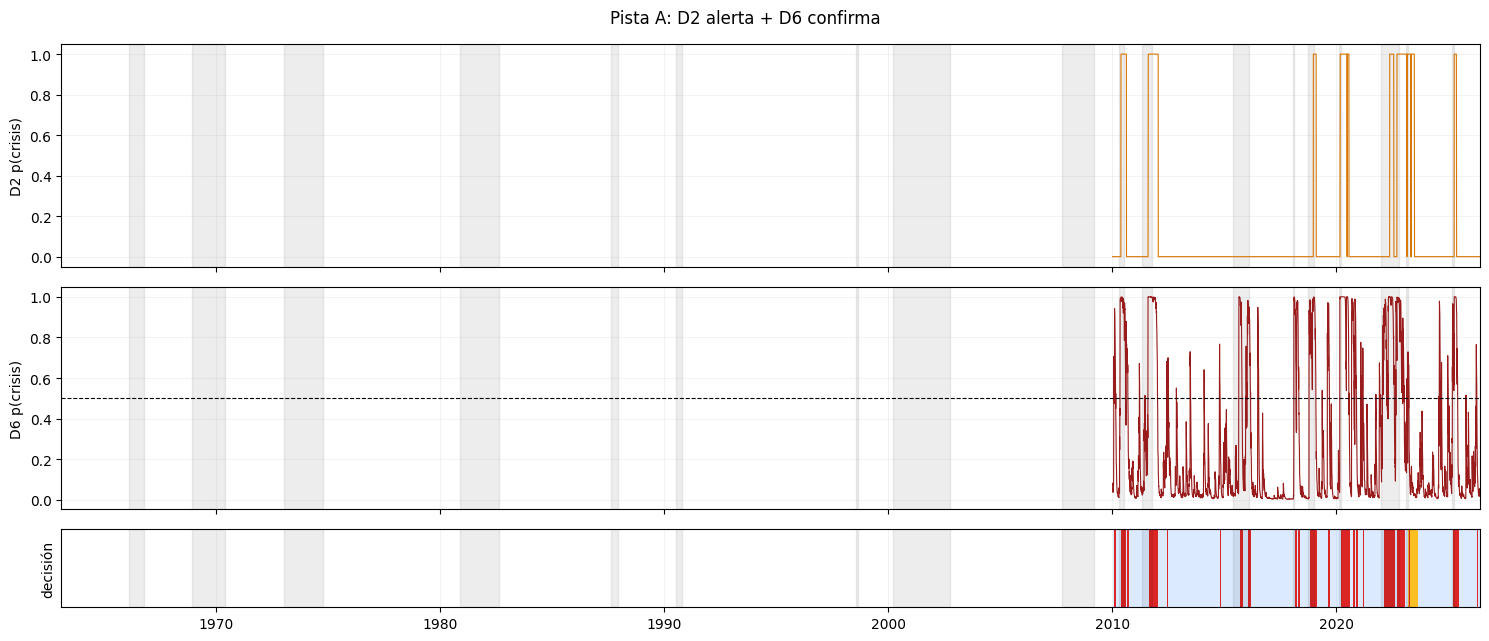

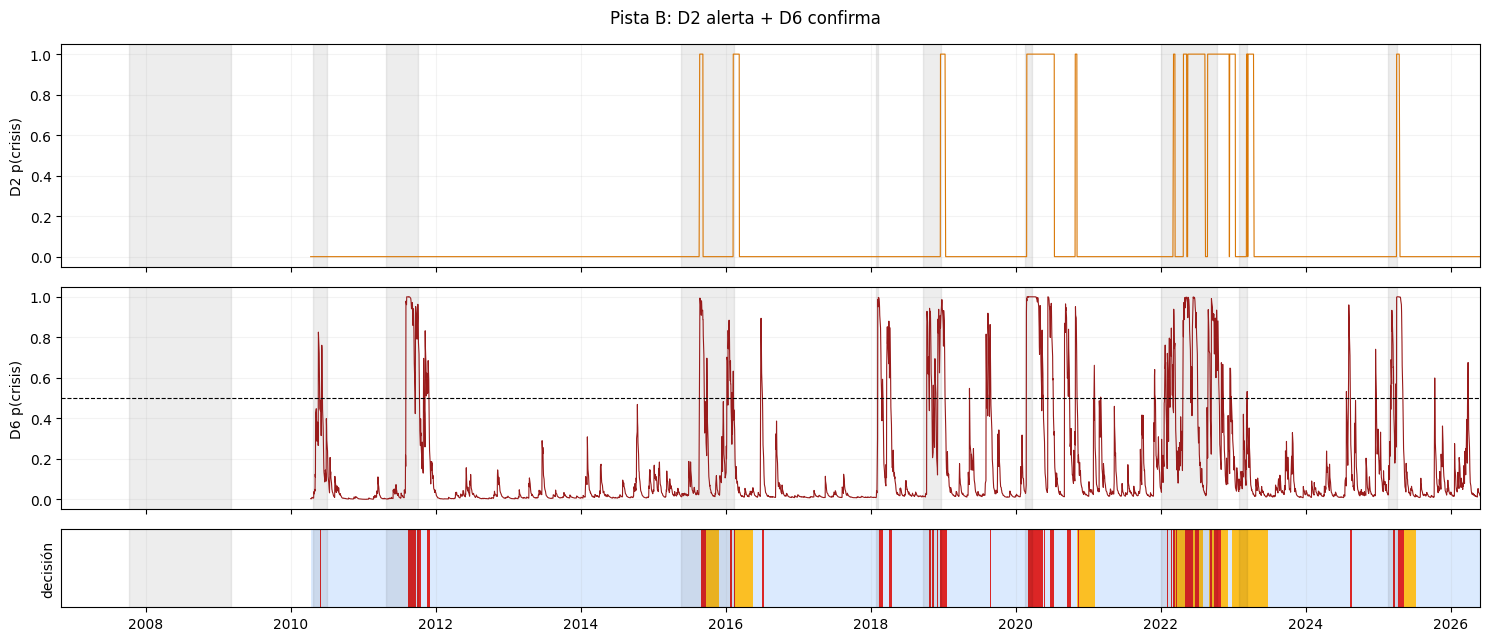

In [7]:
def plot_selected(track, frame):
    configure_evaluation(track)
    view = frame.loc[frame.index >= pd.Timestamp('2010-01-01')]
    colors = ListedColormap(['#dbeafe', '#fbbf24', '#dc2626'])
    fig, axes = plt.subplots(3, 1, figsize=(15, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 0.7]})
    axes[0].plot(view.index, view['alert_probability'], color='#d97706', lw=0.8)
    axes[0].set_ylabel('D2 p(crisis)')
    axes[1].plot(view.index, view['confirmation_probability'], color='#991b1b', lw=0.8)
    axes[1].axhline(CONFIG.confirmation_threshold, color='black', ls='--', lw=0.8)
    axes[1].set_ylabel('D6 p(crisis)')
    axes[2].imshow(view['decision_code'].to_numpy()[None, :], aspect='auto', interpolation='nearest', cmap=colors, vmin=0, vmax=2, extent=[mdates.date2num(view.index[0]), mdates.date2num(view.index[-1]), 0, 1])
    axes[2].set_yticks([]); axes[2].set_ylabel('decisión'); axes[2].xaxis_date()
    for ax in axes:
        for start, end in ev.CRISIS_WINDOWS.values():
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='black', alpha=0.07)
        ax.grid(alpha=0.15)
    fig.suptitle(f'Pista {track}: D2 alerta + D6 confirma')
    fig.tight_layout(); plt.show()

for track in TRACKS:
    plot_selected(track, pair_frames[('D2+D6', track)])

## Conclusión

**D2+D6 se mantiene como la propuesta de esta ronda, con una lectura más acotada:**

1. **Como fusión funciona**: en ambas pistas la decisión accionable D2+D6 tiene mayor utilidad que D2 solo y que D6 solo (`mejora_ambos`; A: −0,033 frente a −0,130 y −0,076; B: −0,199 frente a −0,424 y −0,279) y supera a D7+D8 y D7+D6. Sus días accionables caen en crisis con una precisión ≈0,43, unas 2,2–2,5 veces la fracción de días de crisis (lo que obtendría una señal aleatoria). Matiz: en A, D7 solo (−0,037) queda prácticamente empatado con D2+D6.
2. **No es alerta temprana de crisis**: los avisos de D2 se adelantan a la *confirmación de D6* (mediana 5,5 sesiones en A y 2,5 en B; solo el 6,5% y el 20,5% de las entradas de D6 van precedidas de aviso), pero no al *inicio de las crisis*: 0 avisos de anticipación en A (≈0,9 esperados por azar) y 1 en B (≈1,2). Su valor es detectar pronto *dentro* de la crisis (7 avisos durante crisis en cada pista frente a ≈2,5 y ≈1,7 por azar) con pocas falsas alarmas (5 y 1 frente a ≈8,6 y ≈5,7). En A, 29 de los 42 flancos de D2 llegan cuando D6 ya confirmaba.
3. **La elección de D2 está afectada por sesgo de selección**: su margen sobre el segundo candidato elegible es 0,05 tras probar 11 alertas con la misma muestra. En el control por mitades (sección 5, con los candidatos que tienen panel), seleccionar solo con la primera mitad habría elegido D2 en A pero **D1** en B y en la media A+B; en la segunda mitad D2 queda 2º en A (empatado con D7), 2º de 5 en B y 1º en la media, mientras que D1 cae al último puesto. Es decir, D2 es consistentemente competitivo, pero el orden entre alertas no es estable entre mitades y el cribado completo no demuestra que D2 sea *la* mejor alerta. D4, D5 y D9 (este último 2º en el cribado completo) no entraron en el control por coste de cómputo.

La ganancia no debe interpretarse como evidencia de rentabilidad ni como validación: el siguiente paso correcto es **congelar esta regla (D2 estado de crisis, D6 p≥0,50×3, horizonte 63) y someterla a pseudolive o a un bloque temporal no usado en la selección**, y repetir el control por mitades con los 11 paneles cuando estén disponibles.


In [8]:
if SCREENING_RECOMPUTED:
    # Solo se reescriben si el cribado se recalculó entero desde paneles.
    selection.to_csv(OUTPUT / 'alert_selection.csv')
    candidate_detail.to_csv(OUTPUT / 'alert_selection_by_track.csv', index=False)
comparison.to_csv(OUTPUT / 'pair_warning_comparison.csv', index=False)
pair_scores.to_csv(OUTPUT / 'pair_event_comparison.csv', index=False)
pair_verdict.to_csv(OUTPUT / 'pair_verdict.csv', index=False)
chance_reference.to_csv(OUTPUT / 'chance_reference.csv')
ground_truth_warnings.to_csv(OUTPUT / 'warning_ground_truth.csv', index=False)
phase_vs_chance.to_csv(OUTPUT / 'warning_phase_vs_chance.csv', index=False)
episodes.to_csv(OUTPUT / 'warning_episodes.csv', index=False)
sensitivity.to_csv(OUTPUT / 'sensitivity.csv', index=False)
split_detail.to_csv(OUTPUT / 'split_half_detail.csv', index=False)
split_selection.to_csv(OUTPUT / 'split_half_selection.csv', index=False)
sorted(path.name for path in OUTPUT.glob('*.csv'))

['alert_selection.csv',
 'alert_selection_by_track.csv',
 'chance_reference.csv',
 'pair_event_comparison.csv',
 'pair_verdict.csv',
 'pair_warning_comparison.csv',
 'sensitivity.csv',
 'split_half_detail.csv',
 'split_half_selection.csv',
 'warning_episodes.csv',
 'warning_ground_truth.csv',
 'warning_phase_vs_chance.csv']